In [1]:
import json 
import matplotlib.pyplot as plt
import os
from aeon.visualisation import plot_critical_difference
import pandas as pd

In [2]:
FIGSIZE = (8, 5)
FONTSIZE = 14
FONTSIZE_TITLE = 17

In [3]:
CTX_LEN=1024

In [4]:
dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#573030FF",  # semi-transparent brown
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "Prefix RevIN":              "#FF3300",  # bright red-orange
    "Prefix RevIN + asinh":      "#CC0099",  # strong magenta
}

dic_model_symbols = {
    "Causal RevIN":          "o",   # circle
    "Causal RevIN + asinh":  "x",   # cross
    "RevIN":                 "s",   # square
    "RevIN + asinh":         "d",   # diamond
    "Prefix RevIN":              "^",   # triangle up
    "Prefix RevIN + asinh":      "v",   # triangle down
}

In [5]:
with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_causal_gift_eval = json.load(f)
with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_causal_utsd = json.load(f)
with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_causal_artificial = json.load(f)

with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_causal_asinh_gift_eval = json.load(f)
with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_causal_asinh_utsd = json.load(f)
with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_causal_asinh_artificial = json.load(f)

with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_asinh_gift_eval = json.load(f)
with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_asinh_utsd = json.load(f)
with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_asinh_artificial = json.load(f)

with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_gift_eval = json.load(f)
with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_utsd = json.load(f)
with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_artificial = json.load(f)

with open(os.path.join(f"../results/BaseModel_PrefixRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_Prefix_gift_eval = json.load(f)
with open(os.path.join(f"../results/BaseModel_PrefixRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_Prefix_utsd = json.load(f)
with open(os.path.join(f"../results/BaseModel_PrefixRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_Prefix_artificial = json.load(f)

with open(os.path.join(f"../results/BaseModel_PrefixRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_Prefix_asinh_gift_eval = json.load(f)
with open(os.path.join(f"../results/BaseModel_PrefixRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_Prefix_asinh_utsd = json.load(f)
with open(os.path.join(f"../results/BaseModel_PrefixRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_Prefix_asinh_artificial = json.load(f)

# GIFT-Eval

In [6]:
all_mae_causal, all_rmse_causal, all_mase_causal, sizes = [], [], [], []
for k, v in metrics_causal_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_causal.append(v)
    elif metric.lower() == "rmse":
        all_rmse_causal.append(v)
        sizes.append(size)
    elif metric.lower() == "mase":
        all_mase_causal.append(v)

all_mae_asinh, all_rmse_asinh, all_mase_asinh = [], [], []
for k, v in metrics_asinh_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_asinh.append(v)

all_mae, all_rmse, all_mase = [], [], []
for k, v in metrics_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae.append(v)
    elif metric.lower() == "rmse":
        all_rmse.append(v)
    elif metric.lower() == "mase":
        all_mase.append(v)

all_mae_causal_asinh, all_rmse_causal_asinh, all_mase_causal_asinh = [], [], []
for k, v in metrics_causal_asinh_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_causal_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_causal_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_causal_asinh.append(v)

all_mae_Prefix, all_rmse_Prefix, all_mase_Prefix = [], [], []
for k, v in metrics_Prefix_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_Prefix.append(v)
    elif metric.lower() == "rmse":
        all_rmse_Prefix.append(v)
    elif metric.lower() == "mase":
        all_mase_Prefix.append(v)
        
all_mae_Prefix_asinh, all_rmse_Prefix_asinh, all_mase_Prefix_asinh = [], [], []
for k, v in metrics_Prefix_asinh_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_Prefix_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_Prefix_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_Prefix_asinh.append(v)

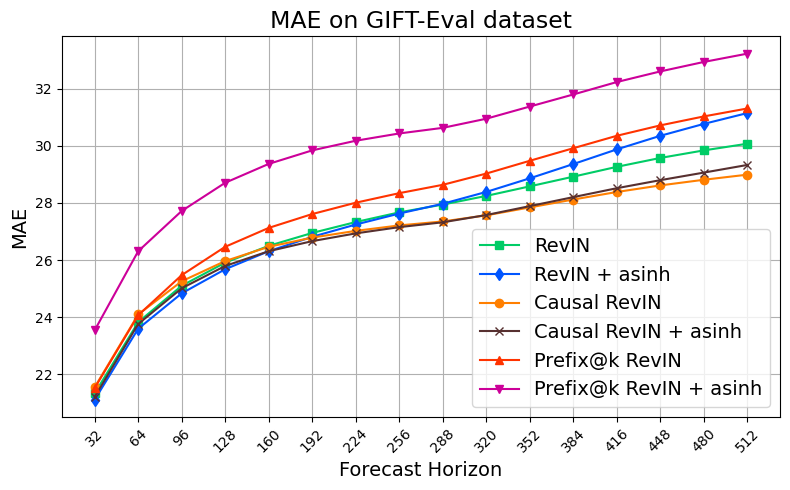

In [7]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"], )
plt.plot(all_mae_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_mae_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_mae_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_mae_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mae_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/mae_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

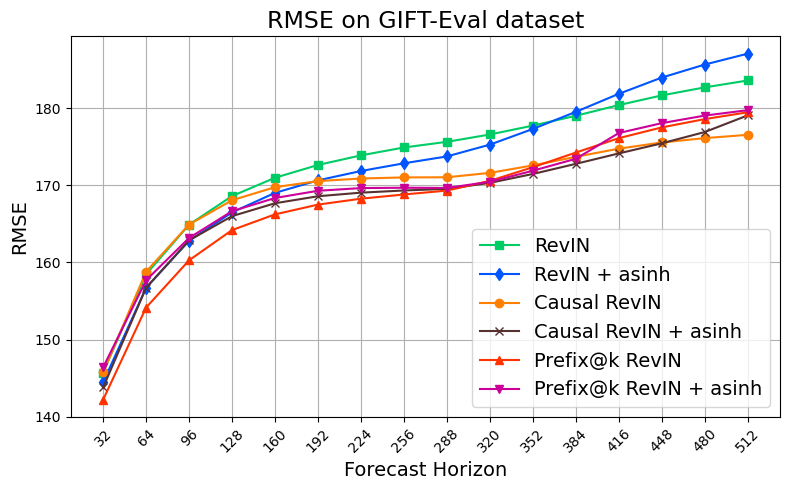

In [8]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"])
plt.plot(all_rmse_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_rmse_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_rmse_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_rmse_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_rmse_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/rmse_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

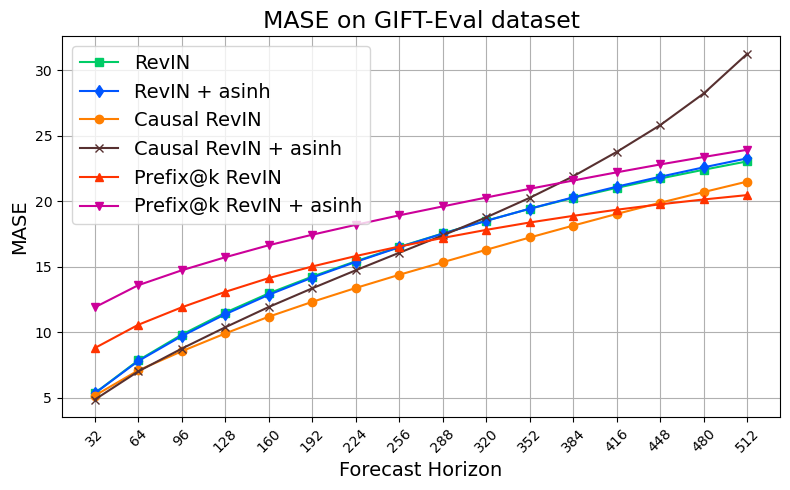

In [9]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"])
plt.plot(all_mase_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_mase_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_mase_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_mase_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mase_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/mase_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# UTSD

In [10]:
all_mae_causal, all_rmse_causal, all_mase_causal,  sizes = [], [], [], []
for k, v in metrics_causal_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_causal.append(v)
    elif metric.lower() == "rmse":
        all_rmse_causal.append(v)
        sizes.append(size)
    elif metric.lower() == "mase":
        all_mase_causal.append(v)

all_mae_asinh, all_rmse_asinh, all_mase_asinh = [], [], []
for k, v in metrics_asinh_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_asinh.append(v)

all_mae, all_rmse, all_mase = [], [], []
for k, v in metrics_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae.append(v)
    elif metric.lower() == "rmse":
        all_rmse.append(v)
    elif metric.lower() == "mase":
        all_mase.append(v)

all_mae_causal_asinh, all_rmse_causal_asinh, all_mase_causal_asinh = [], [], []
for k, v in metrics_causal_asinh_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_causal_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_causal_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_causal_asinh.append(v)

all_mae_Prefix, all_rmse_Prefix, all_mase_Prefix = [], [], []
for k, v in metrics_Prefix_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_Prefix.append(v)
    elif metric.lower() == "rmse":
        all_rmse_Prefix.append(v)
    elif metric.lower() == "mase":
        all_mase_Prefix.append(v)

all_mae_Prefix_asinh, all_rmse_Prefix_asinh, all_mase_Prefix_asinh = [], [], []
for k, v in metrics_Prefix_asinh_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_Prefix_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_Prefix_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_Prefix_asinh.append(v)

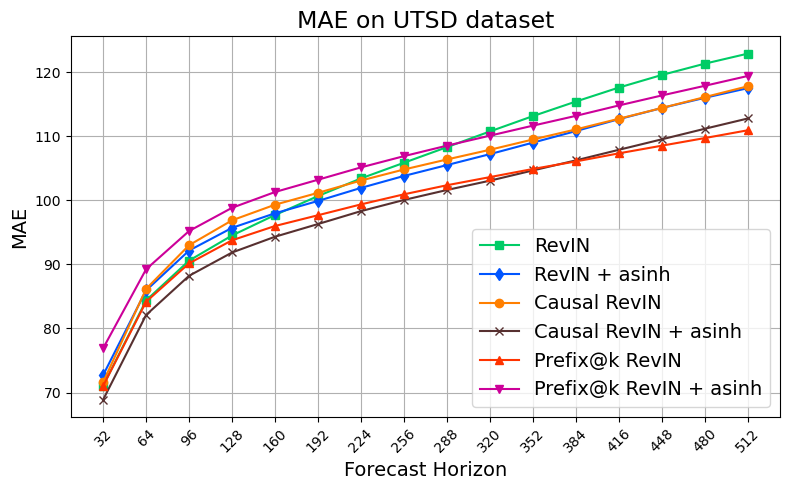

In [11]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"], )
plt.plot(all_mae_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_mae_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_mae_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_mae_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mae_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/mae_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

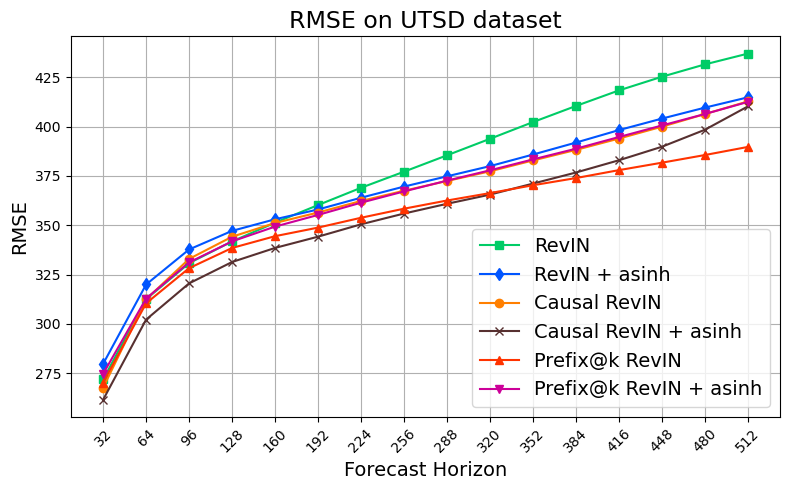

In [12]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"])
plt.plot(all_rmse_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_rmse_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_rmse_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_rmse_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_rmse_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/rmse_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

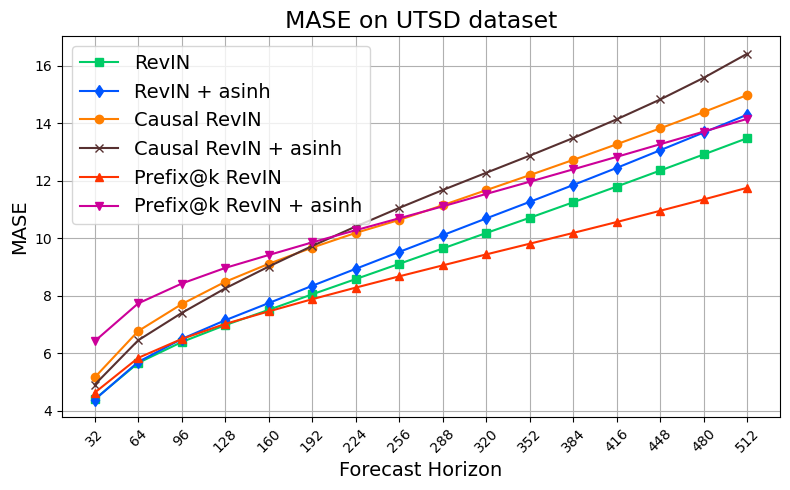

In [13]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"])
plt.plot(all_mase_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_mase_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_mase_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_mase_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mase_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/mase_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# Artificial

In [14]:
all_mae_causal, all_rmse_causal, all_mase_causal,  sizes = [], [], [], []
for k, v in metrics_causal_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_causal.append(v)
    elif metric.lower() == "rmse":
        all_rmse_causal.append(v)
        sizes.append(size)
    elif metric.lower() == "mase":
        all_mase_causal.append(v)

all_mae_asinh, all_rmse_asinh, all_mase_asinh = [], [], []
for k, v in metrics_asinh_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_asinh.append(v)

all_mae, all_rmse, all_mase = [], [], []
for k, v in metrics_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae.append(v)
    elif metric.lower() == "rmse":
        all_rmse.append(v)
    elif metric.lower() == "mase":
        all_mase.append(v)

all_mae_causal_asinh, all_rmse_causal_asinh, all_mase_causal_asinh = [], [], []
for k, v in metrics_causal_asinh_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_causal_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_causal_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_causal_asinh.append(v)

all_mae_Prefix, all_rmse_Prefix, all_mase_Prefix = [], [], []
for k, v in metrics_Prefix_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_Prefix.append(v)
    elif metric.lower() == "rmse":
        all_rmse_Prefix.append(v)
    elif metric.lower() == "mase":
        all_mase_Prefix.append(v)

all_mae_Prefix_asinh, all_rmse_Prefix_asinh, all_mase_Prefix_asinh = [], [], []
for k, v in metrics_Prefix_asinh_artificial.items(): 
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_Prefix_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_Prefix_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_Prefix_asinh.append(v)

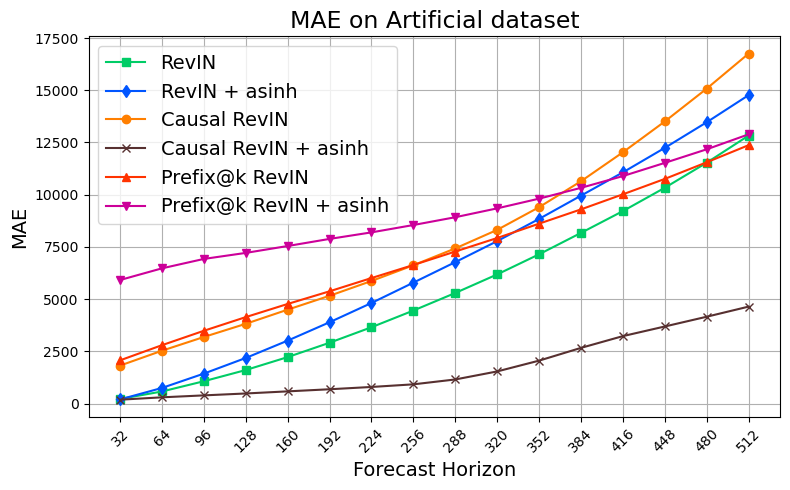

In [15]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"], )
plt.plot(all_mae_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_mae_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_mae_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_mae_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mae_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/mae_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

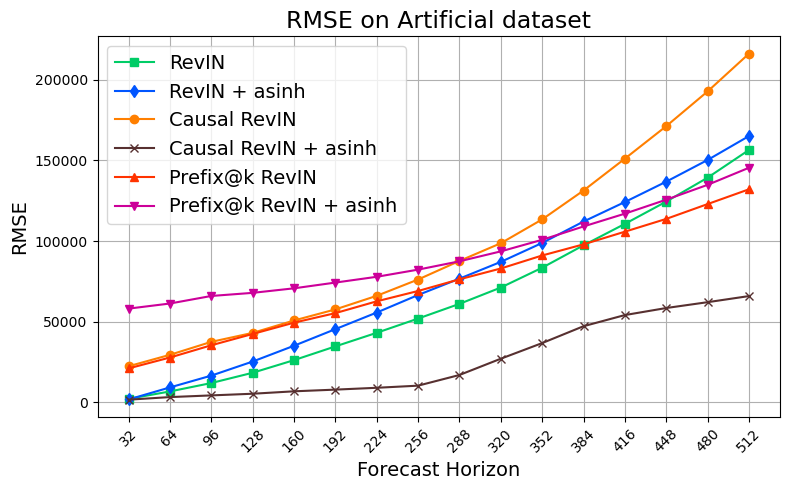

In [16]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"])
plt.plot(all_rmse_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_rmse_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_rmse_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_rmse_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_rmse_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/rmse_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

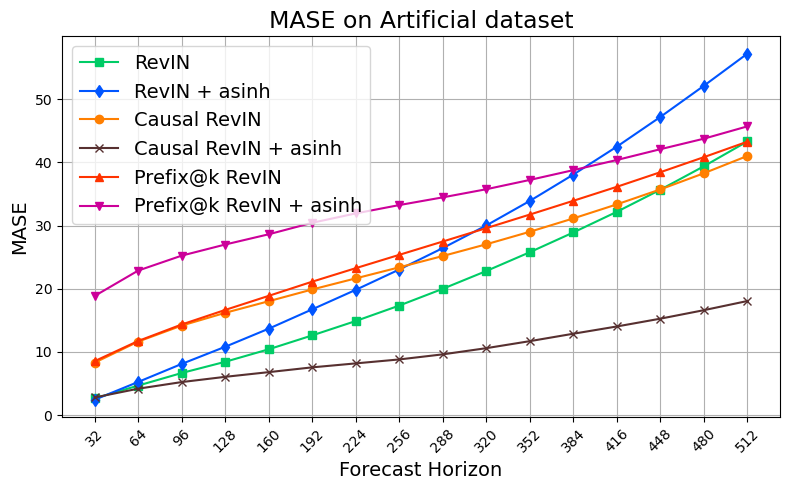

In [17]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase, marker=dic_model_symbols["RevIN"], label="RevIN", color=dic_model_colors["RevIN"])
plt.plot(all_mase_asinh, marker=dic_model_symbols["RevIN + asinh"], label="RevIN + asinh", color=dic_model_colors["RevIN + asinh"])
plt.plot(all_mase_causal, marker=dic_model_symbols["Causal RevIN"], label="Causal RevIN", color=dic_model_colors["Causal RevIN"])
plt.plot(all_mase_causal_asinh, marker=dic_model_symbols["Causal RevIN + asinh"], label="Causal RevIN + asinh", color=dic_model_colors["Causal RevIN + asinh"])
plt.plot(all_mase_Prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mase_Prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
plt.savefig(f'figures/plots/mase_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# Critical Rank Diagram

In [18]:
full_df = {}
full_df['Causal RevIN'] = {
    #'GIFT': metrics_causal_gift,
    'GIFT-Eval': metrics_causal_gift_eval,
    'UTSD': metrics_causal_utsd,
    'Artificial': metrics_causal_artificial
}
full_df['Causal RevIN + asinh'] = {
    #'GIFT': metrics_causal_asinh_gift,
    'GIFT-Eval': metrics_causal_asinh_gift_eval,
    'UTSD': metrics_causal_asinh_utsd,
    'Artificial': metrics_causal_asinh_artificial
}
full_df['RevIN + asinh'] = {
    #'GIFT': metrics_asinh_gift,
    'GIFT-Eval': metrics_asinh_gift_eval,
    'UTSD': metrics_asinh_utsd,
    'Artificial': metrics_asinh_artificial
}
full_df['RevIN'] = {
    #'GIFT': metrics_gift,
    'GIFT-Eval': metrics_gift_eval,
    'UTSD': metrics_utsd,
    'Artificial': metrics_artificial
}
full_df['Prefix RevIN'] = {
    #'GIFT': metrics_Prefix_gift,
    'GIFT-Eval': metrics_Prefix_gift_eval,
    'UTSD': metrics_Prefix_utsd,
    'Artificial': metrics_Prefix_artificial
}
full_df['Prefix RevIN + asinh'] = {
    #'GIFT': metrics_Prefix_asinh_gift,
    'GIFT-Eval': metrics_Prefix_asinh_gift_eval,
    'UTSD': metrics_Prefix_asinh_utsd,
    'Artificial': metrics_Prefix_asinh_artificial
}

In [19]:
new_df_mae = {}
new_df_mse = {}
new_df_mase = {}
for model_name, datasets in full_df.items():
    new_df_mae[model_name] = {}
    new_df_mse[model_name] = {}
    new_df_mase[model_name] = {}
    for dataset_name, metrics in datasets.items():
        for k, v in metrics.items():
            metric, size = k.split("_")
            if metric.lower() == "mae":
                new_df_mae[model_name][f"{dataset_name}_{size}"] = v
            elif metric.lower() == "rmse":
                new_df_mse[model_name][f"{dataset_name}_{size}"] = v 
            elif metric.lower() == "mase":
                new_df_mase[model_name][f"{dataset_name}_{size}"] = v

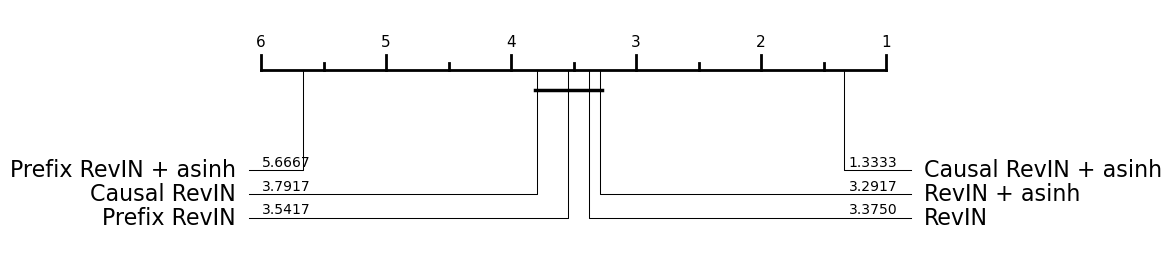

In [20]:
# Create Critical Difference plot for MAE
df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

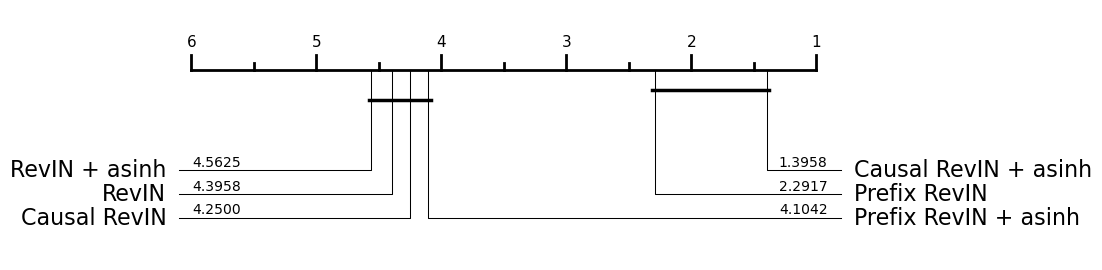

In [21]:
# Create Critical Difference plot for MAE
df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

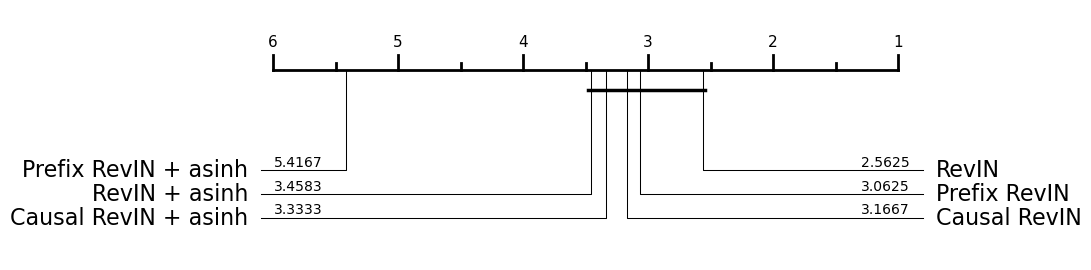

In [22]:
# Create Critical Difference plot for MASE
df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

In [23]:
# overall with all context lengths
CTX_LENS = [128, 256, 512, 1024]
full_df = {}
for CTX_LEN in CTX_LENS:

    with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_causal_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_causal_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_CausalRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_causal_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_causal_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_causal_asinh_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_CausalRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_causal_asinh_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_asinh_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_RevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_asinh_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_RevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_PrefixRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_Prefix_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_PrefixRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_Prefix_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_PrefixRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_Prefix_artificial = json.load(f)

    with open(os.path.join(f"../results/BaseModel_PrefixRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_Prefix_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../results/BaseModel_PrefixRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_Prefix_asinh_utsd = json.load(f)
    with open(os.path.join(f"../results/BaseModel_PrefixRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_Prefix_asinh_artificial = json.load(f)
    
    full_df[CTX_LEN] = {}
    full_df[CTX_LEN]['Causal RevIN'] = {
        'GIFT-Eval': metrics_causal_gift_eval,
        'UTSD': metrics_causal_utsd,
        'Artificial': metrics_causal_artificial
    }
    full_df[CTX_LEN]['Causal RevIN + asinh'] = {
        'GIFT-Eval': metrics_causal_asinh_gift_eval,
        'UTSD': metrics_causal_asinh_utsd,
        'Artificial': metrics_causal_asinh_artificial
    }
    full_df[CTX_LEN]['RevIN + asinh'] = {
        'GIFT-Eval': metrics_asinh_gift_eval,
        'UTSD': metrics_asinh_utsd,
        'Artificial': metrics_asinh_artificial
    }
    full_df[CTX_LEN]['RevIN'] = {
        'GIFT-Eval': metrics_gift_eval,
        'UTSD': metrics_utsd,
        'Artificial': metrics_artificial
    }
    full_df[CTX_LEN]['Prefix RevIN'] = {
        'GIFT-Eval': metrics_Prefix_gift_eval,
        'UTSD': metrics_Prefix_utsd,
        'Artificial': metrics_Prefix_artificial
    }
    full_df[CTX_LEN]['Prefix RevIN + asinh'] = {
        'GIFT-Eval': metrics_Prefix_asinh_gift_eval,
        'UTSD': metrics_Prefix_asinh_utsd,
        'Artificial': metrics_Prefix_asinh_artificial
    }
new_df_mae = {}
new_df_mse = {}
for CTX_LEN in CTX_LENS:
    for model_name, datasets in full_df[CTX_LEN].items():
        key_prefix = f"{model_name}"
        if key_prefix not in new_df_mae:
            new_df_mae[key_prefix] = {}
            new_df_mse[key_prefix] = {}
        for dataset_name, metrics in datasets.items():
            for k, v in metrics.items():
                metric, size = k.split("_")
                if metric.lower() == "mae":
                    new_df_mae[key_prefix][f"{dataset_name}_{CTX_LEN}_{size}"] = v
                elif metric.lower() == "rmse":
                    new_df_mse[key_prefix][f"{dataset_name}_{CTX_LEN}_{size}"] = v

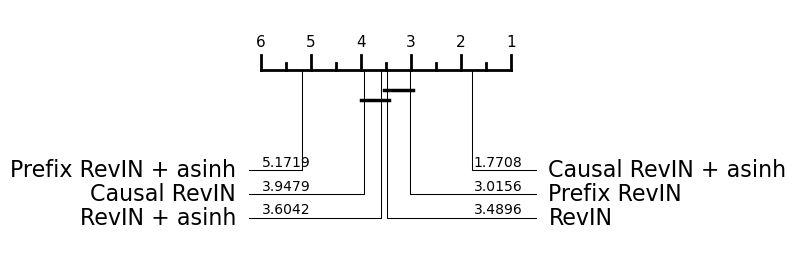

In [24]:
#MAE

df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=4, textspace=1, test='nemenyi', lower_better=True)
plt.savefig("figures/cd_plot_mae_all_context_lengths.pdf", bbox_inches='tight', dpi=300)

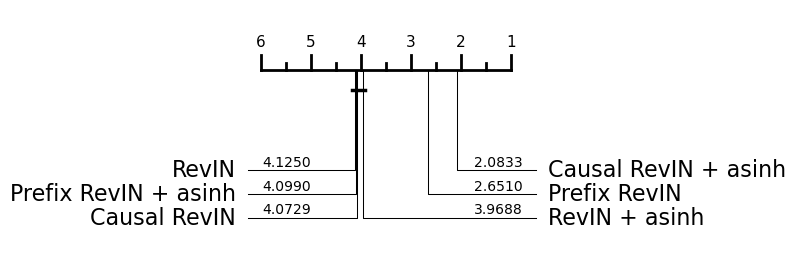

In [25]:
#MSE

df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=5, test='nemenyi', lower_better=True)
plt.savefig("figures/cd_plot_mse_all_context_lengths.pdf", bbox_inches='tight', dpi=300)

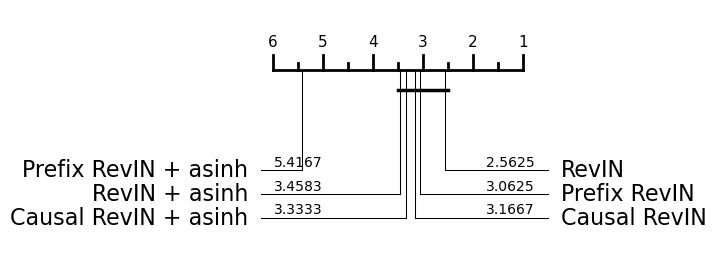

In [26]:
#MASE

df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=4, textspace=1, test='nemenyi', lower_better=True)
plt.savefig("figures/cd_plot_mase_all_context_lengths.pdf", bbox_inches='tight', dpi=300)